# Lista 8 (10 pkt.)

In [33]:
import numpy as np
import matplotlib.pyplot as plt

## Zadanie 1 (2 pkt.)

Napisz funkcję **gen(a,b,p)**, która generuje listę punktów reprezentujących krzywą eliptyczną nad $\mathbb{Z}_p$ o równaniu $y^2=(x^3+ax+b)\mod p$.

In [34]:
def gen(a,b,p):
    points = []
    for x in range(p):
        rhs = (x**3 + a*x + b) % p
        for y in range(p):
            if (y**2) % p == rhs:
                points.append([x, y])
    return points

In [35]:
print(gen(-1,0,7)==[[0, 0], [1, 0], [4, 2], [4, 5], [5, 1], [5, 6], [6, 0]])
print(gen(-1,0,11)==[[0, 0], [1, 0], [4, 4], [4, 7], [6, 1], [6, 10], [8, 3], [8, 8], [9, 4], [9, 7], [10, 0]])
print(gen(-1,1,7)==[[0, 1], [0, 6], [1, 1], [1, 6], [2, 0], [3, 2], [3, 5], [5, 3], [5, 4], [6, 1], [6, 6]])
print(gen(0,2,5)==[[2, 0], [3, 2], [3, 3], [4, 1], [4, 4]])

True
True
True
True


## Zadanie 2 (2 pkt.)

Napisz funkcję **add(P,Q,a,p)**, która dodaje do siebie punkty $P$ i $Q$ na krzywej eliptycznej nad ciałem $\mathbb{Z}_p$ z parametrem $a$. Wykorzystaj wzory z wykładu.

$$x_3 = \left(s^2-x_1-x_2\right) \mod p$$
$$y_3 = \left(s\left(x_1-x_3\right)-y_1 \right) \mod p$$

$$s=\frac{y_2-y_1}{x_2-x_1} \mod p \quad P\neq Q$$
$$s=\frac{3x_1^2+a}{2y_1} \mod p \quad P=Q$$

$(x_3, y_3)$ to współrzędne punktu będącego sumą punktów $(x_1, y_1)$ i $(x_2, y_2)$. Natomiast $a$ to współczynnik z równania krzywej.

Uwaga 1: wszystkie operacje w tych wzorach są na ciele $\mathbb{Z}_p$ zatem tam gdzie mamy dzielenie mamy tak naprawdę mnożenie przez odwrotność w tym ciele, wykorzystaj tutaj funkcję **inv** z poprzedniej listy, może być potrzeba ją nieco zmodyfikować, ponieważ może się tu pojawić dzielenie przez zero, które daje nam punkt "w nieskończości" (na wykładzie: $\mathcal{O}$).

Uwaga 2: Uwzględnij również, że zarówno w wyniku dodawania jak i w argumentach dodawanie może pojawić się punkt "w nieskończoności", zwracaj go jako **nan**, tj. za pomocą **float('nan')**, do sprawdzania czy coś jest **nan** użyj **np.isnan()**.

In [36]:
def inv(n, p):
    return pow(n, p-2, p)

def add(P,Q,a,p):
    if np.isnan(P).any():
        return Q
    if np.isnan(Q).any():
        return P

    x1, y1 = P
    x2, y2 = Q

    if x1 == x2 and (y1 + y2) % p == 0:
        return [float('nan'), float('nan')]

    if P != Q:
        dx = (x2 - x1) % p
        dy = (y2 - y1) % p
        if dx == 0:
             return [float('nan'), float('nan')]
        s = (dy * inv(dx, p)) % p
    else:
        if y1 == 0:
             return [float('nan'), float('nan')]
        numerator = (3 * x1**2 + a) % p
        denominator = (2 * y1) % p
        s = (numerator * inv(denominator, p)) % p

    x3 = (s**2 - x1 - x2) % p
    y3 = (s * (x1 - x3) - y1) % p

    return [x3, y3]

In [37]:
print(add([4,2],[5,1],-1,7)==[6,0])
print(add([4,2],[4,2],-1,7)==[1,0])
print(add([4,2],[5,1],-1,7)==[6,0])
print(add([4,2],[float('nan'),float('nan')],-1,7)==[4,2])
print(np.isnan(add([float('nan'),float('nan')],[float('nan'),float('nan')],-1,7)))
print(np.isnan(add([0,0],[0,0],-1,7)))
print(add([2,0],[3,2],0,5)==[4,1])
print(np.isnan(add([2,0],[2,0],0,5)))

True
True
True
True
[ True  True]
[ True  True]
True
[ True  True]


W oparciu o poprzednią funkcję napisz funkcję **multiply(n,P,a,p)**, która mnoży punkt $P$ razy liczbę naturalną $n$ na krzywej eliptycznej nad ciałem $\mathbb{Z}_p$ z parametrem $a$, tzn. dodaje ten punkt do siebie $n$ razy.

In [38]:
def multiply(n,P,a,p):
    if n == 0:
        return [float('nan'), float('nan')]
    if n == 1:
        return P
    
    result = P
    for _ in range(n - 1):
        result = add(result, P, a, p)
        
    return result

In [39]:
print(multiply(1,[4,2],-1,7)==[4,2])
print(multiply(1,[4,2],-1,7)==[4,2])
print(multiply(3,[4,2],-1,7)==[4,5])
print(np.isnan(multiply(4,[4,2],-1,7)))
print(np.isnan(multiply(2,[float('nan'),float('nan')],-1,7)))
print(multiply(5,[2,0],0,5)==[2,0])
print(multiply(5,[3,3],0,5)==[3,2])

True
True
True
[ True  True]
[ True  True]
True
True


## Zadanie 3 (2 pkt.)

Narysuj na wykresie punkty (**plt.scatter()**) reprezentujące krzywą eliptyczną. Stosując funkcję **multiply()** przeanalizuj jaką grupę generuje każdy z punktów tej krzywej, wypisz te grupy. Nie automatyzuj tego, tzn. operacje na punktach wykonuj stosując wcześniejsze funkcje ale analizę poszczególnych grup przeprowadź ręcznie.

Na przykład dla krzywej $y^2=x^3-5x$ nad ciałem $\mathbb{Z}_5$ mamy 5 punktów (łącznie z punktem w nieskończoności, którego nie ma na wykresie, 6 punktów):

<img src="fig.png" width="500"/>

Punkt $P_0$ generuje dwuelementową grupę:

{$P_0,\mathcal{O}$},

bo $2P_0=\mathcal{O}$,

punkt $P_1$ generuje pięcioelementową grupę:

{$P_1,P_3,P_4,P_2,\mathcal{O}$}

bo $2P_1=P_3,3P_1=P_4,4P_1=P_2,5P_1=\mathcal{O}$

pozostałe elementy $P_2,P_3,P_4$ generują dokładnie tą samą grupę, zatem na tej krzywej mamy określone dwie grupy jedną dwuelementową i jedną pięcioelementową.

Przeprowadź podobną analizę dla przykładów:
1. krzywa nad ciałem $\mathbb{Z}_7$ o równaniu $y^2=x^3-x$
2. krzywa nad ciałem $\mathbb{Z}_5$ o równaniu $y^2=x^3-2x+1$

--- Analiza krzywej y^2 = x^3 - x (mod 7) ---
Punkt P=[0, 0]:
  2P = [nan, nan]
  Rząd: 2, Grupa: [[0, 0], 'O']

Punkt P=[1, 0]:
  2P = [nan, nan]
  Rząd: 2, Grupa: [[1, 0], 'O']

Punkt P=[4, 2]:
  2P = [1, 0], 3P = [4, 5], 4P = [nan, nan]
  Rząd: 4, Grupa: [[4, 2], [1, 0], [4, 5], 'O']

Punkt P=[4, 5]:
  2P = [1, 0], 3P = [4, 2], 4P = [nan, nan]
  Rząd: 4, Grupa: [[4, 5], [1, 0], [4, 2], 'O']

Punkt P=[5, 1]:
  2P = [1, 0], 3P = [5, 6], 4P = [nan, nan]
  Rząd: 4, Grupa: [[5, 1], [1, 0], [5, 6], 'O']

Punkt P=[5, 6]:
  2P = [1, 0], 3P = [5, 1], 4P = [nan, nan]
  Rząd: 4, Grupa: [[5, 6], [1, 0], [5, 1], 'O']

Punkt P=[6, 0]:
  2P = [nan, nan]
  Rząd: 2, Grupa: [[6, 0], 'O']

Wnioski dla Z_7 (y^2=x^3-x):
Istnieją grupy 2-elementowe (generowane przez [0,0], [1,0], [6,0]) oraz grupy 4-elementowe.



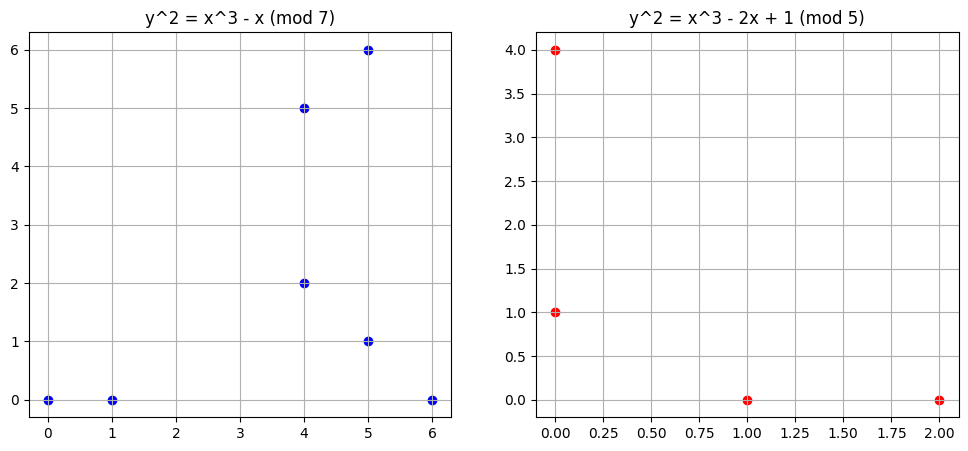

--- Analiza krzywej y^2 = x^3 - 2x + 1 (mod 5) ---
Punkt P=[0, 1]:
  2P = [1, 0], 3P = [0, 4], 4P = [nan, nan]
  Rząd: 4, Grupa: [[0, 1], [1, 0], [0, 4], 'O']

Punkt P=[0, 4]:
  2P = [1, 0], 3P = [0, 1], 4P = [nan, nan]
  Rząd: 4, Grupa: [[0, 4], [1, 0], [0, 1], 'O']

Punkt P=[1, 0]:
  2P = [nan, nan]
  Rząd: 2, Grupa: [[1, 0], 'O']

Punkt P=[2, 0]:
  2P = [nan, nan]
  Rząd: 2, Grupa: [[2, 0], 'O']

Wnioski dla Z_5 (y^2=x^3-2x+1):
Mamy jedną grupę 2-elementową, dwie grupy 3-elementowe (będące podgrupą grupy 6-el) i dwie grupy 6-elementowe (cała grupa punktów).


In [40]:
# Analiza Przypadek 1: y^2 = x^3 - x na Z_7 (a=-1, b=0, p=7)
a1, b1, p1 = -1, 0, 7
points1 = gen(a1, b1, p1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
xs1 = [p[0] for p in points1]
ys1 = [p[1] for p in points1]
plt.scatter(xs1, ys1, color='blue')
plt.title(f"y^2 = x^3 - x (mod {p1})")
plt.grid(True)

print(f"--- Analiza krzywej y^2 = x^3 - x (mod {p1}) ---")
for i, P in enumerate(points1):
    group_elements = [P]
    current = P
    output_str = f"Punkt P={P}:\n  "
    
    for n in range(2, len(points1) + 5):
        current = add(current, P, a1, p1)
        if np.isnan(current).any():
            output_str += f"{n}P = [nan, nan]"
            group_elements.append("O")
            break
        else:
            output_str += f"{n}P = {current}, "
            group_elements.append(current)
            
    print(output_str)
    print(f"  Rząd: {len(group_elements)}, Grupa: {group_elements}\n")

print("Wnioski dla Z_7 (y^2=x^3-x):")
print("Istnieją grupy 2-elementowe (generowane przez [0,0], [1,0], [6,0]) oraz grupy 4-elementowe.\n")


# Analiza Przypadek 2: y^2 = x^3 - 2x + 1 na Z_5 (a=-2, b=1, p=5)
a2, b2, p2 = -2, 1, 5
points2 = gen(a2, b2, p2)

plt.subplot(1, 2, 2)
xs2 = [p[0] for p in points2]
ys2 = [p[1] for p in points2]
plt.scatter(xs2, ys2, color='red')
plt.title(f"y^2 = x^3 - 2x + 1 (mod {p2})")
plt.grid(True)
plt.show()

print(f"--- Analiza krzywej y^2 = x^3 - 2x + 1 (mod {p2}) ---")
for i, P in enumerate(points2):
    group_elements = [P]
    current = P
    output_str = f"Punkt P={P}:\n  "
    
    for n in range(2, len(points2) + 5):
        current = add(current, P, a2, p2)
        if np.isnan(current).any():
            output_str += f"{n}P = [nan, nan]"
            group_elements.append("O")
            break
        else:
            output_str += f"{n}P = {current}, "
            group_elements.append(current)
            
    print(output_str)
    print(f"  Rząd: {len(group_elements)}, Grupa: {group_elements}\n")

print("Wnioski dla Z_5 (y^2=x^3-2x+1):")
print("Mamy jedną grupę 2-elementową, dwie grupy 3-elementowe (będące podgrupą grupy 6-el) i dwie grupy 6-elementowe (cała grupa punktów).")

## Zadanie 4 (1 pkt)

Sprawdź numerycznie, korzystając z funkcji **gen()**, twierdzenie Hassego. Sprawdź, że ze wzrostem liczby pierwszej $p$ dla krzywej o parametrach $a=-1$, $b=0$ liczba punktów na krzywej podąża za oszacowaniem $p+1-2\sqrt{p}\leq\#E\leq p+1+2\sqrt{p}$. Narysuj wykres $\#E(p)$ i proste o równaniach $p+1-2\sqrt{p}$ oraz $p+1+2\sqrt{p}$.

Uwaga: Możesz wygenerować liczby pierwsze, np. w zakresie od 0 do 1000, za pomocą:

In [41]:
from sympy import primerange
primes = list(primerange(0, 1000)) 

lub jakkolwiek inaczej.

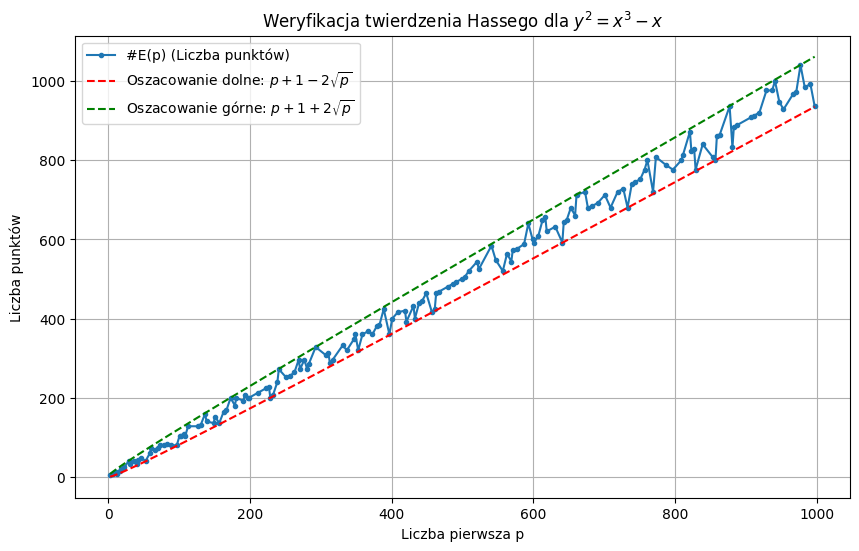

In [42]:
counts = []
lower_bound = []
upper_bound = []
valid_primes = []

a, b = -1, 0

for p in primes:
    if p == 2: continue
    
    points = gen(a, b, p)
    count = len(points) + 1
    
    counts.append(count)
    valid_primes.append(p)
    
    lower_bound.append(p + 1 - 2 * np.sqrt(p))
    upper_bound.append(p + 1 + 2 * np.sqrt(p))

plt.figure(figsize=(10, 6))
plt.plot(valid_primes, counts, 'o-', label='#E(p) (Liczba punktów)', markersize=3)
plt.plot(valid_primes, lower_bound, 'r--', label='Oszacowanie dolne: $p+1-2\sqrt{p}$')
plt.plot(valid_primes, upper_bound, 'g--', label='Oszacowanie górne: $p+1+2\sqrt{p}$')
plt.xlabel('Liczba pierwsza p')
plt.ylabel('Liczba punktów')
plt.title('Weryfikacja twierdzenia Hassego dla $y^2 = x^3 - x$')
plt.legend()
plt.grid(True)
plt.show()

## Zadanie 5 (2 pkt.)

Napisz funkcję **ord(G,a,p)** znajdującą rząd punktu $G$ na krzywej o parametrach $a$, $p$ (oznaczenia jak w poprzednich zadaniach). Rząd elementu to $n$ takie, że $nG=\mathcal{O}$. Znajdź punkt na krzywej o parametrach $a=-1$,$b=0$,$p=97$ o największym rzędzie, moze ich być więcej niż jeden, wybierz którykolwiek.

In [43]:
def ord(G,a,p):
    if np.isnan(G).any(): return 1
    
    current = G
    n = 1
    while True:
        current = add(current, G, a, p)
        n += 1
        if np.isnan(current).any():
            return n
        if n > 2*p + 10: 
             return 0

In [44]:
print(ord([4,4],-1,11)==3)
print(ord([8,8],-1,11)==6)
print(ord([3,2],-1,7)==3)
print(ord([3,5],-1,7)==3)
print(ord([3,2],0,5)==3)
print(ord([0,0],0,5)==2)

True
True
True
True
True
True


In [45]:
a_tgt, b_tgt, p_tgt = -1, 0, 97
points_97 = gen(a_tgt, b_tgt, p_tgt)

max_order = 0
max_order_point = None

for P in points_97:
    order = ord(P, a_tgt, p_tgt)
    if order > max_order:
        max_order = order
        max_order_point = P

print(f"Punkt o maksymalnym rzędzie: {max_order_point}, Rząd: {max_order}")

Punkt o maksymalnym rzędzie: [6, 4], Rząd: 20


## Zadanie 6 (1 pkt)

Prześledź działanie protokołu Diffiego-Helmana, jednak tym razem opertego o krzywe eliptyczne, i uzupełnij poszczególne kroki.

Alicja i Bob ustalają publicznie krzywą eliptyczą (czyli parametry $a$, $b$, $p$) w której będą działać oraz punkt na tej krzywej $G$. Weź krzywą z poprzedniego zadania oraz znaleziony w nim punkt.

In [46]:
a = -1
b = 0
p = 97
G = max_order_point


Alicja wybiera losową liczbę naturalną $n$ z przedziału $[2,\#E-1]$, $\#E$ to liczba punktów na krzywej:

In [47]:
import random
E_count = len(points_97) + 1 
n = random.randint(2, E_count - 1)
print(f"Alicja wybrała n: {n}")

Alicja wybrała n: 16


Następnie oblicza $A=nG$ zgodnie z zasadami mnożenia punktów na krzywej przez liczbe naturalną:

In [48]:
A = multiply(n, G, a, p)
print(f"Klucz publiczny Alicji A: {A}")

Klucz publiczny Alicji A: [94, 48]


To samo robi Bob, wybiera losową liczbę naturalną $m$ i oblicza $B=mG$:

In [49]:
m = random.randint(2, E_count - 1)
B = multiply(m, G, a, p)
print(f"Bob wybrał m: {m}")
print(f"Klucz publiczny Boba B: {B}")

Bob wybrał m: 71
Klucz publiczny Boba B: [16, 54]


Liczby $n$ i $m$ są znane tylko, odpowiednio, Alicji i Bobowi, natomiast $A$ oraz $B$ są wymieniane publicznym kanałem. Bob otrzymuje $A$ i wykonuje operację $k_B=mA$, z kolei Alicja otrzymuje $B$ i wykonuje operację $k_A=nB$:

In [50]:
k_B = multiply(m, A, a, p)
k_A = multiply(n, B, a, p)
print(f"Wspólny sekret obliczony przez Alicję: {k_A}")
print(f"Wspólny sekret obliczony przez Boba:   {k_B}")

Wspólny sekret obliczony przez Alicję: [94, 48]
Wspólny sekret obliczony przez Boba:   [94, 48]


In [51]:
k_A==k_B

True

Zawuażmy, że $k_A=k_B$, wynika to z tego, że $k_A=nB=nmG$ oraz $k_B=mA=mnG$ a oczywiście $nm=mn$. Zatem Alicja i Bob dysponują tą samą liczbą, którą mogą użyć jako klucz do szyfrowania. Publicznie znane są wartości $a$, $b$, $p$, $G$, $nG$ oraz $mG$, jednak odzyskanie z nich $n$ i $m$ jest bardzo trudne przy odpwiednim doborze krzywej i punktu na niej.